<a href="https://colab.research.google.com/github/gez2code/dermamnist-hybrid-study/blob/main/Experiment_Setup_Modular.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Random seed set to 42
Loading DermaMNIST...
Data Loaded. Class Weights: {0: np.float64(0.5542635658914729), 1: np.float64(5.107142857142857)}

--- Visualizing Data Quality ---


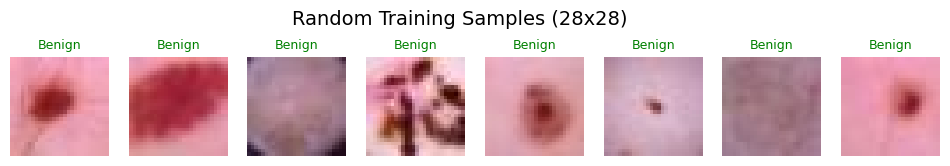

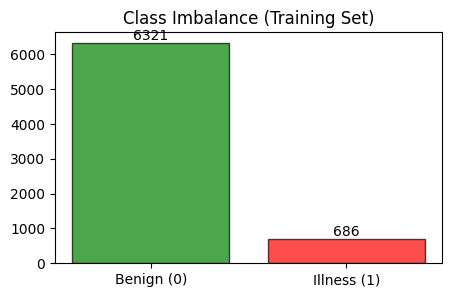

In [18]:
# ==========================================
# 1. INSTALL & IMPORT DEPENDENCIES
# ==========================================
# We install 'medmnist' for the dataset and 'wandb' for experiment tracking.
!pip install medmnist wandb -q

import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from medmnist import DermaMNIST
import wandb
from wandb.integration.keras import WandbMetricsLogger
import matplotlib.pyplot as plt

# Metrics and utilities for evaluation
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ==========================================
# 2. REPRODUCIBILITY SETUP
# ==========================================
# Setting seeds ensures that if we run the same code twice, we get the same results.
# This is crucial for scientific comparisons between models.
SEED = 42
def set_seeds(seed=SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
    np.random.seed(seed)

set_seeds()
print(f"Random seed set to {SEED}")

# ==========================================
# 3. DATA LOADING, VISUALIZATION & PREPROCESSING
# ==========================================
def load_and_prep_data():
    print("Loading DermaMNIST...")
    # 'size=28' ensures we respect the native resolution
    train_data = DermaMNIST(split='train', download=True, size=28)
    val_data = DermaMNIST(split='val', download=True, size=28)
    test_data = DermaMNIST(split='test', download=True, size=28)

    # --- 1. PREPROCESSING (Normalization) ---
    x_train, y_train = train_data.imgs.astype('float32')/255.0, train_data.labels
    x_val, y_val = val_data.imgs.astype('float32')/255.0, val_data.labels
    x_test, y_test = test_data.imgs.astype('float32')/255.0, test_data.labels

    # --- 2. BINARY MAPPING (7 Classes -> 2 Classes) ---
    # 0=Benign, 1=Illness (Melanoma, BCC, etc.)
    to_binary = lambda y: np.isin(y, [0, 1, 6]).astype(int)
    y_train_bin, y_val_bin, y_test_bin = to_binary(y_train), to_binary(y_val), to_binary(y_test)

    # --- 3. ONE-HOT ENCODING ---
    y_train_enc = tf.keras.utils.to_categorical(y_train_bin, 2)
    y_val_enc = tf.keras.utils.to_categorical(y_val_bin, 2)
    y_test_enc = tf.keras.utils.to_categorical(y_test_bin, 2)

    # --- 4. CLASS WEIGHTS (Fix Imbalance) ---
    cw = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train_bin),
        y=y_train_bin.flatten()
    )
    weights = {0: cw[0], 1: cw[1]}
    print(f"Data Loaded. Class Weights: {weights}")

    # --- 5. VISUALIZATION (Internal Helper) ---
    print("\n--- Visualizing Data Quality ---")

    # Plot Samples
    plt.figure(figsize=(12, 2))
    indices = np.random.choice(len(x_train), 8, replace=False)
    for i, idx in enumerate(indices):
        plt.subplot(1, 8, i+1)
        plt.imshow(x_train[idx])
        plt.axis('off')
        label = "Illness" if y_train_bin[idx] == 1 else "Benign"
        color = 'red' if label == "Illness" else 'green'
        plt.title(label, color=color, fontsize=9)
    plt.suptitle("Random Training Samples (28x28)", fontsize=14)
    plt.show()

    # Plot Distribution
    unique, counts = np.unique(y_train_bin, return_counts=True)
    plt.figure(figsize=(5, 3))
    bars = plt.bar(["Benign (0)", "Illness (1)"], counts, color=['green', 'red'], alpha=0.7, edgecolor='black')
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{bar.get_height()}', ha='center', va='bottom')
    plt.title("Class Imbalance (Training Set)")
    plt.show()

    return (x_train, y_train_enc), (x_val, y_val_enc), (x_test, y_test_enc), weights

# Load Data Once
(x_train, y_train), (x_val, y_val), (x_test, y_test), class_weights = load_and_prep_data()

# ==========================================
# 4. UNIVERSAL TRAINER FUNCTION
# ==========================================
# This function handles the entire lifecycle of an experiment:
# Init W&B -> Build Model -> Train -> Evaluate -> Log Results
def train_experiment(model_builder, exp_name, config):
    # 1. Init W&B
    if wandb.run is not None: wandb.finish()
    wandb.init(project="DermaMNIST_Project", name=exp_name, config=config)

    # 2. Build & Compile with BETTER METRICS
    d_rate = config.get('dropout', 0.5)
    model = model_builder(dropout_rate=d_rate)

    # --- OPTIMIZER SELECTION LOGIC ---
    lr = config.get('learning_rate', 0.001)
    opt_name = config.get('optimizer', 'adam').lower()

    if opt_name == 'sgd':
        # SGD requires "Momentum" to work well on images.
        # momentum=0.9 is the gold standard value.
        print(f"Using SGD Optimizer (LR={lr}, Momentum=0.9)")
        optimizer = optimizers.SGD(learning_rate=lr, momentum=0.9)
    else:
        print(f"Using Adam Optimizer (LR={lr})")
        optimizer = optimizers.Adam(learning_rate=lr)


    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            # <--- NEW: Track these LIVE to spot "Benign-only" cheating
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )

    # --- NEW STEP 2b: Generate & Log Architecture Diagram ---
    # This creates the image file locally
    image_path = f"{exp_name}_arch.png"
    tf.keras.utils.plot_model(
        model,
        to_file=image_path,
        show_shapes=True,
        show_layer_names=True
    )

    # This uploads it to the W&B dashboard
    print(f"Logging architecture diagram: {image_path}")
    wandb.log({"model_architecture": wandb.Image(image_path)})
    # --------------------------------------------------------

    # 3. Train with SCIENTIFICALLY VALID Augmentation
    # Removed 'shear_range' (skin doesn't shear).
    # Added 'zoom_range' (cameras move closer/further).
    datagen = ImageDataGenerator(
        rotation_range=20,      # Increased slightly to handle orientation
        width_shift_range=0.1,  # Reduced shift (keep lesion centered)
        height_shift_range=0.1,
        zoom_range=0.1,         # <--- NEW: Simulates different distances
        horizontal_flip=True,
        vertical_flip=True,     # <--- NEW: Lesions have no "up" or "down"
        fill_mode='nearest'
    )

    print(f"\nStarting Experiment: {exp_name}")
    history = model.fit(
        datagen.flow(x_train, y_train, batch_size=config['batch_size'], seed=SEED),
        epochs=config['epochs'],
        validation_data=(x_val, y_val),
        class_weight=class_weights,
        callbacks=[
            WandbMetricsLogger(),
            # <--- NEW: Squeeze more performance out of the model
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,       # Cut LR in half
                patience=3,       # If no improvement for 3 epochs
                verbose=1,
                min_lr=1e-6
            )
        ],
        verbose=1
    )

    # 4. EVALUATE & VISUALIZE
    print("\nGenerating Test Predictions...")
    y_pred_probs = model.predict(x_test)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)

    from sklearn.metrics import accuracy_score, roc_auc_score
    test_acc = accuracy_score(y_true_classes, y_pred_classes)
    test_auc = roc_auc_score(y_test, y_pred_probs)

    report_dict = classification_report(y_true_classes, y_pred_classes, target_names=['Benign', 'Illness'], output_dict=True)

    wandb.log({
        "test_accuracy": test_acc,
        "test_auc": test_auc,
        "test_recall_illness": report_dict['Illness']['recall'],
        "test_precision_illness": report_dict['Illness']['precision']
    })

    wandb.log({"roc_curve": wandb.plot.roc_curve(y_true_classes, y_pred_probs, labels=["Benign", "Illness"])})
    wandb.log({"conf_mat": wandb.plot.confusion_matrix(probs=None, y_true=y_true_classes, preds=y_pred_classes, class_names=["Benign", "Illness"])})

    print(classification_report(y_true_classes, y_pred_classes, target_names=['Benign', 'Illness']))
    wandb.finish()

In [19]:
# ==========================================
# 5. MODEL ARCHITECTURES
# ==========================================

# --- MODEL 1: THE BASELINE CNN ---
# A simple, standard architecture to establish a performance benchmark.
# It uses single convolution layers followed by pooling.
def build_baseline_cnn(dropout_rate=0.5):
    # We use a lower dropout rate for convolutional layers to avoid losing too much spatial info.
    conv_drop = dropout_rate * 0.5

    model = models.Sequential([
        layers.Input(shape=(28, 28, 3)),

        # Layer 1: Detects basic edges/colors
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(conv_drop),

        # Layer 2: Detects simple shapes
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(conv_drop),

        # Layer 3: Detects complex textures
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Classifier Head
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(dropout_rate), # Stronger dropout before final classification
        layers.Dense(2, activation='softmax')
    ])
    return model

# --- MODEL 2: VGG-STYLE (DEEP) ---
# Mimics the famous VGG network by stacking two convolutions before every pooling layer.
# This increases the "receptive field" and non-linearity without shrinking the image too fast.
def build_vgg_style(dropout_rate=0.5):
    conv_drop = dropout_rate * 0.5

    model = models.Sequential([
        layers.Input(shape=(28, 28, 3)),

        # Block 1: Double Conv for better feature extraction at high resolution
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(conv_drop),

        # Block 2: Double Conv for mid-level features
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(conv_drop),

        # Classifier Head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(2, activation='softmax')
    ])
    return model

# --- MODEL 3: RESNET-STYLE (MODERN) ---
# Uses "Skip Connections" (shortcuts) to allow gradients to flow easily.
# This prevents the "vanishing gradient" problem and is very stable.
def build_resnet_style(dropout_rate=0.5):

    # Helper function for a Residual Block
    def res_block(x, filters, stride=1):
        shortcut = x

        # Main Path
        x = layers.Conv2D(filters, (3, 3), strides=stride, padding='same')(x)
        x = layers.BatchNormalization()(x) # BN is crucial for ResNet stability
        x = layers.Activation('relu')(x)
        x = layers.Conv2D(filters, (3, 3), padding='same')(x)
        x = layers.BatchNormalization()(x)

        # Shortcut Path: Resize input if dimensions change
        if stride > 1 or shortcut.shape[-1] != filters:
            shortcut = layers.Conv2D(filters, (1, 1), strides=stride, padding='same')(shortcut)
            shortcut = layers.BatchNormalization()(shortcut)

        # The Skip Connection: Add original input to the processed output
        x = layers.Add()([x, shortcut])
        x = layers.Activation('relu')(x)
        return x

    # --- FIX: INDENTATION CORRECTED HERE ---
    inputs = layers.Input(shape=(28, 28, 3))

    # Initial Conv to process the raw image
    x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Stack Residual Blocks
    x = res_block(x, 32)             # Keep 28x28
    x = res_block(x, 64, stride=2)   # Downsample to 14x14
    x = res_block(x, 128, stride=2)  # Downsample to 7x7

    # Global Average Pooling replaces Flatten (Drastically reduces parameters)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(2, activation='softmax')(x)

    return models.Model(inputs, outputs)

In [20]:
# ==========================================
# 6. RUNNING THE EXPERIMENTS
# ==========================================

## --- Experiment 1: Baseline CNN ---
train_experiment(
    model_builder=build_baseline_cnn,
    exp_name="Exp1_Baseline_Optimized",
    config={
        "architecture": "Baseline_CNN",
        "optimizer": "adam",

        # BATCH SIZE: 32
        # Why? Small batches add "noise" to the gradient, which acts as a
        # regularizer and helps the model escape local minima (e.g., "always predict Benign").
        "batch_size": 32,

        # EPOCHS: 30
        # Why? Shallow networks usually converge fast. 30 is enough to see a plateau.
        "epochs": 30,

        # LEARNING RATE: 0.001 (1e-3)
        # Why? Standard starting point for Adam. Shallow nets are stable enough to handle this speed.
        "learning_rate": 0.001,

        # DROPOUT: 0.25 (Light)
        # Why? This model has fewer parameters (~500k). If you use 0.5 dropout,
        # you might kill too many neurons and make it underfit (too dumb to learn).
        "dropout": 0.25
    }
)

Using Adam Optimizer (LR=0.001)
Logging architecture diagram: Exp1_Baseline_Optimized_arch.png

Starting Experiment: Exp1_Baseline_Optimized
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


219/219 ━━━━━━━━━━━━━━━━━━━━ 29s 55ms/step - accuracy: 0.6550 - auc: 0.7057 - loss: 0.6717 - precision: 0.6550 - recall: 0.6550 - val_accuracy: 0.6700 - val_auc: 0.7900 - val_loss: 0.5420 - val_precision: 0.6700 - val_recall: 0.6700 - learning_rate: 0.0010
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.6966 - auc: 0.8088 - loss: 0.4986 - precision: 0.6966 - recall: 0.6966 - val_accuracy: 0.7687 - val_auc: 0.8759 - val_loss: 0.4426 - val_precision: 0.7687 - val_recall: 0.7687 - learning_rate: 0.0010
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7639 - auc: 0.8647 - loss: 0.4346 - precision: 0.7639 - recall: 0.7639 - val_accuracy: 0.8305 - val_auc: 0.9335 - val_loss: 0.3510 - val_precision: 0.8305 - val_recall: 0.8305 - learning_rate: 0.0010
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.7609 - auc: 0.8667 - loss: 0.4386 - precision: 0.7609 - recall: 0.7609 - val_accuracy: 0.8076 - val_auc: 0.9208 - val_loss: 0.3627 - val_preci

epoch/accuracy,▁▃▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇█▇███████
epoch/auc,▁▄▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇█▇███████████
epoch/epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
epoch/learning_rate,██████████████▄▄▄▄▄▄▃▃▃▂▂▂▁▁▁▁
epoch/loss,█▅▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁
epoch/precision,▁▃▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇█▇███████
epoch/recall,▁▃▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇█▇███████
epoch/val_accuracy,▁▄▅▅▄▆▃▃▆▇▇▅▅▄▇▆█▆█▇▆▇▇▆█▇▇▇▇▇
epoch/val_auc,▁▄▇▆▅▇▂▂▇▇█▇▅▄█▇█▇██▇█▇▇██▇█▇█
epoch/val_loss,█▆▄▄▅▃██▃▂▁▃▅▆▁▂▁▂▁▂▃▁▂▃▁▁▂▂▂▂
+6,...


In [21]:
# --- Experiment 2: VGG-Style ---
train_experiment(
    model_builder=build_vgg_style,
    exp_name="Exp2_VGG_Optimized",
    config={
        "architecture": "VGG_Style",
        "optimizer": "adam",

        # BATCH SIZE: 32
        # Critical here because VGG has many parameters. 32 ensures frequent updates.
        "batch_size": 32,

        # EPOCHS: 40 (Extended)
        # Why? We are using a very low learning rate (below), so the model needs
        # more time (epochs) to slowly walk down the loss curve.
        "epochs": 40,

        # LEARNING RATE: 0.0001 (1e-4)
        # Why? Deep networks without skip connections are unstable.
        # A high LR (0.001) would cause the loss to "explode" or spike. We slow it down 10x.
        "learning_rate": 0.0001,

        # DROPOUT: 0.5 (Heavy)
        # Why? VGG is huge. It will easily memorize the training data.
        # We delete 50% of the neurons randomly to force it to learn robust patterns.
        "dropout": 0.5
    }
)

Using Adam Optimizer (LR=0.0001)
Logging architecture diagram: Exp2_VGG_Optimized_arch.png

Starting Experiment: Exp2_VGG_Optimized
Epoch 1/40


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.5623 - auc: 0.5898 - loss: 0.6736 - precision: 0.5623 - recall: 0.5623 - val_accuracy: 0.6939 - val_auc: 0.8225 - val_loss: 0.4919 - val_precision: 0.6939 - val_recall: 0.6939 - learning_rate: 1.0000e-04
Epoch 2/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.6418 - auc: 0.7555 - loss: 0.5690 - precision: 0.6418 - recall: 0.6418 - val_accuracy: 0.6750 - val_auc: 0.8171 - val_loss: 0.4850 - val_precision: 0.6750 - val_recall: 0.6750 - learning_rate: 1.0000e-04
Epoch 3/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.6531 - auc: 0.7779 - loss: 0.5363 - precision: 0.6531 - recall: 0.6531 - val_accuracy: 0.7797 - val_auc: 0.9053 - val_loss: 0.3681 - val_precision: 0.7797 - val_recall: 0.7797 - learning_rate: 1.0000e-04
Epoch 4/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.6941 - auc: 0.8177 - loss: 0.5062 - precision: 0.6941 - recall: 0.6941 - val_accuracy: 0.7876 - val_auc: 0.9098 - val_loss: 0.3646

epoch/accuracy,▁▃▄▄▅▅▅▆▆▇▇▇▇▇▇▇████████████████████████
epoch/auc,▁▅▅▆▆▆▇▇▇▇▇█████████████████████████████
epoch/epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
epoch/learning_rate,███████▄▄▄▄▄▄▄▄▃▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▅▅▄▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/precision,▁▃▄▄▅▅▅▆▆▇▇▇▇▇▇▇████████████████████████
epoch/recall,▁▃▄▄▅▅▅▆▆▇▇▇▇▇▇▇████████████████████████
epoch/val_accuracy,▂▁▅▅▄▃▅▅▅▆▄█▆▇▅▆▅▅▆▇▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆
epoch/val_auc,▁▁▆▆▄▃▆▅▅▇▄█▆▇▅▆▄▄▇▇▆▇▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆
epoch/val_loss,██▄▄▆▇▄▅▅▃▇▁▄▃▅▄▇▇▃▃▄▃▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄
+6,...


In [22]:
# --- Experiment 3: ResNet-Style ---
train_experiment(
    model_builder=build_resnet_style,
    exp_name="Exp3_ResNet_Optimized",
    config={
        "architecture": "ResNet_Custom",
        "optimizer": "adam",

        "batch_size": 32,
        "epochs": 30,

        # LEARNING RATE: 0.0005 (5e-4)
        # Why? Skip connections make the gradient flow smoother than VGG.
        # We can afford to train 5x faster than VGG (0.0005 vs 0.0001) without crashing.
        # This is the "Sweet Spot" for ResNets.
        "learning_rate": 0.0005,

        # DROPOUT: 0.5 (Standard)
        # Why? Even though ResNet is smarter, it's still deep.
        # 0.5 is the industry standard for the final classification layer.
        "dropout": 0.5
    }
)

Using Adam Optimizer (LR=0.0005)
Logging architecture diagram: Exp3_ResNet_Optimized_arch.png

Starting Experiment: Exp3_ResNet_Optimized
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


219/219 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.6982 - auc: 0.7845 - loss: 0.6069 - precision: 0.6982 - recall: 0.6982 - val_accuracy: 0.0987 - val_auc: 0.1350 - val_loss: 2.8259 - val_precision: 0.0987 - val_recall: 0.0987 - learning_rate: 5.0000e-04
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.7787 - auc: 0.8806 - loss: 0.4285 - precision: 0.7787 - recall: 0.7787 - val_accuracy: 0.5852 - val_auc: 0.6434 - val_loss: 0.7449 - val_precision: 0.5852 - val_recall: 0.5852 - learning_rate: 5.0000e-04
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.7983 - auc: 0.8941 - loss: 0.3967 - precision: 0.7983 - recall: 0.7983 - val_accuracy: 0.7039 - val_auc: 0.8170 - val_loss: 0.5714 - val_precision: 0.7039 - val_recall: 0.7039 - learning_rate: 5.0000e-04
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.7975 - auc: 0.8939 - loss: 0.3984 - precision: 0.7975 - recall: 0.7975 - val_accuracy: 0.7069 - val_auc: 0.7908 - val_loss: 0.6223

epoch/accuracy,▁▃▄▄▅▅▅▅▆▆▆▆▆▆▇▆▇▇▇▇█▇████████
epoch/auc,▁▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇█▇████████
epoch/epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
epoch/learning_rate,██████████████▄▄▄▃▃▃▂▂▂▁▁▁▁▁▁▁
epoch/loss,█▆▅▅▅▄▄▄▃▃▃▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
epoch/precision,▁▃▄▄▅▅▅▅▆▆▆▆▆▆▇▆▇▇▇▇█▇████████
epoch/recall,▁▃▄▄▅▅▅▅▆▆▆▆▆▆▇▆▇▇▇▇█▇████████
epoch/val_accuracy,▁▅▆▆▆▆▆█▆▄█▇█▆▇█▆▇▇███████████
epoch/val_auc,▁▅▇▆▇▇▇█▆▄█▇█▇██▇█████████████
epoch/val_loss,█▂▂▂▂▂▂▁▂▄▁▂▁▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁
+6,...
